# Biometric Fraud Detection Lab: Analysis Walkthrough
A hybrid rule-based + Isolation Forest pipeline that detects fraud in synthetic biometric authentication logs. This notebook walks through the data, the detection logic, how it was tuned, and the final results.

Run `bash run_pipeline.sh` from the project root first to generate all data and outputs.

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
import pandas as pd
from IPython.display import Image, Markdown, display
pd.set_option('display.max_columns', 20)

## 1. The data
Synthetic logs for 200 users over 30 days. Each user has a home city and takes occasional whole-day trips. Four fraud patterns are injected at a ~6% rate: **low-score bypass**, **geo-jump** (impossible travel), **rapid retry** (brute force) and **off-hours** access.

In [2]:
raw = pd.read_csv('data/raw/biometric_auth_logs.csv', parse_dates=['timestamp'])
print(f"{len(raw):,} events, {raw['is_fraud'].sum()} fraud")
display(raw.head())
raw['fraud_pattern'].value_counts()

7,327 events, 414 fraud


,event_id,user_id,timestamp,modality,match_score,device_id,location,attempt_count,outcome,session_duration_sec,is_fraud,fraud_pattern
0,8345d6d3-3d72-4c0e-a3ed-6309e25c2f4a,USR-0025,2024-01-01 02:06:00,keystroke_dynamics,0.7493,DEV-0009,London,1,success,227,True,off_hours
1,adc1e2f7-5de4-40f7-97f4-d848fbd3d538,USR-0181,2024-01-01 02:25:00,keystroke_dynamics,0.8010,DEV-0032,Manchester,1,success,226,True,off_hours
2,e19d4f0a-1c44-4135-a9d4-de06342ed9b4,USR-0082,2024-01-01 03:51:00,face,0.8385,DEV-0030,Manchester,1,success,127,True,off_hours
3,e0222432-7ca5-4928-97dd-06916a71efda,USR-0036,2024-01-01 04:06:00,voice,0.7950,DEV-0044,New York,1,success,168,True,off_hours
4,e586ee20-c73e-49e9-9806-9315ce62665f,USR-0178,2024-01-01 04:30:00,voice,0.9181,DEV-0041,New York,1,success,197,True,off_hours


,count
fraud_pattern,
geo_jump,114
low_score_bypass,110
off_hours,106
rapid_retry,84


## 2. Detection logic
- **Rules** (explainable): match score < 0.55, attempts >= 8, off-hours, per-user score z-score > 2.5, and speed-based impossible travel (> 900 km/h between consecutive logins). Impossible travel alerts alone; other rules need two signals to agree.
- **Isolation Forest** (unsupervised): catches unusual combinations the rules don't encode.
- **Correlation**: a legitimate login straight after a fraudster's foreign login looks like impossible travel too (the *return leg*). If it has no other suspicious signal, it is linked to the existing incident instead of raising a new alert.

In [3]:
df = pd.read_csv('data/processed/flagged_events.csv', parse_dates=['timestamp'])
from sklearn.metrics import classification_report
print(classification_report(df['is_fraud'].astype(int), df['alert'],
                            target_names=['Legitimate', 'Fraud'], digits=3))

              precision    recall  f1-score   support

  Legitimate      0.999     0.997     0.998      6913
       Fraud      0.953     0.986     0.969       414

    accuracy                          0.996      7327
   macro avg      0.976     0.991     0.984      7327
weighted avg      0.997     0.996     0.996      7327



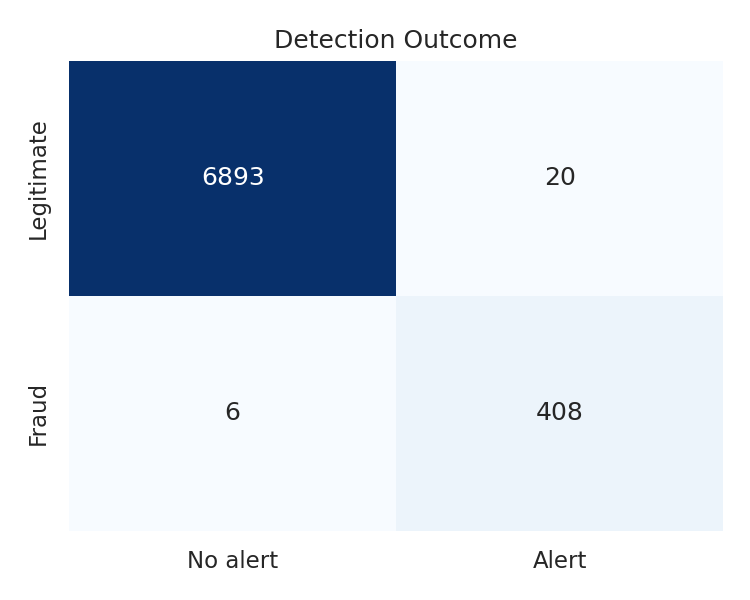

In [4]:
display(Image('reports/confusion_matrix.png', width=420))

### Example: an impossible-travel incident and its return leg

In [5]:
leg = df[df['suppressed'] == 1].iloc[0]
u = df[df['user_id'] == leg['user_id']].sort_values('timestamp')
i = u.index.get_loc(leg.name)
cols = ['user_id', 'timestamp', 'location', 'travel_speed_kmh', 'impossible_travel',
        'return_leg', 'alert', 'suppressed', 'is_fraud', 'fraud_pattern']
u.iloc[max(i - 2, 0): i + 1][cols]

,user_id,timestamp,location,travel_speed_kmh,impossible_travel,return_leg,alert,suppressed,is_fraud,fraud_pattern
160,USR-0005,2024-01-23 10:04:00,London,0.000000,0,0,0,0,False,NaN
161,USR-0005,2024-01-23 10:18:00,Singapore,46490.763732,1,0,1,0,True,geo_jump
162,USR-0005,2024-01-23 13:31:00,London,3372.387006,1,1,0,1,False,NaN


## 3. How the detection was tuned
The first version produced 414 false positives. Root-causing them drove three iterations.

In [6]:
display(Markdown(open('reports/tuning_log.md').read()))

# Detection tuning log

## Iterations
| Version | Change | FP | FN | Precision | Recall |
|---|---|---|---|---|---|
| v1 | Naive rule (any location change within 60 min), random-city data | 414 | 4 | 50.2% | 99.0% |
| v2 | Realistic data (home city + whole-day trips), same naive rule | 31 | 3 | 93.0% | 99.3% |
| v3 | Speed-based rule (>900 km/h), realistic data | 59 | 6 | 87.4% | 98.6% |
| v4 | v3 + return-leg correlation | 20 | 6 | 95.3% | 98.6% |

**Key findings**
- v1 to v2: 411 of 414 false positives came from impossible travel. Root cause was unrealistic
  synthetic data (users teleporting between cities), not the detector.
- v3: speed-based rule (haversine distance / time) is physically correct but also flags the
  "return leg" - the real user logging in from home after a fraudster's foreign login.
- v4: return legs with no other suspicious signal are linked to the existing incident instead
  of raising a new alert. 39 suppressed, 0 of them fraud.
- Note: v1 and v2 used different generated datasets (7,453 vs 7,327 events); v2 to v4 used the same data.

## Isolation Forest contamination sweep (v4)
| contamination | alerts | precision | recall |
|---|---|---|---|
| 0.01 | 287 | 99.7% | 69.1% |
| 0.02 | 291 | 99.7% | 70.0% |
| 0.04 | 337 | 99.1% | 80.7% |
| 0.06 | 428 | 95.3% | 98.6% |
| 0.08 | 556 | 73.9% | 99.3% |

**Chosen: 0.06.** Recall collapses below it and precision collapses above it.
Caveat: 0.06 is close to the true fraud rate (~5.7%), which a production system would not know;
in practice this would be tuned against analyst feedback on closed alerts.


## 4. Results by fraud pattern

In [7]:
fraud = df[df['is_fraud']]
fraud.groupby('fraud_pattern')['alert'].agg(events='size', detected='sum', recall='mean')

,events,detected,recall
fraud_pattern,,,
geo_jump,114,114,1.000000
low_score_bypass,110,106,0.963636
off_hours,106,106,1.000000
rapid_retry,84,82,0.976190


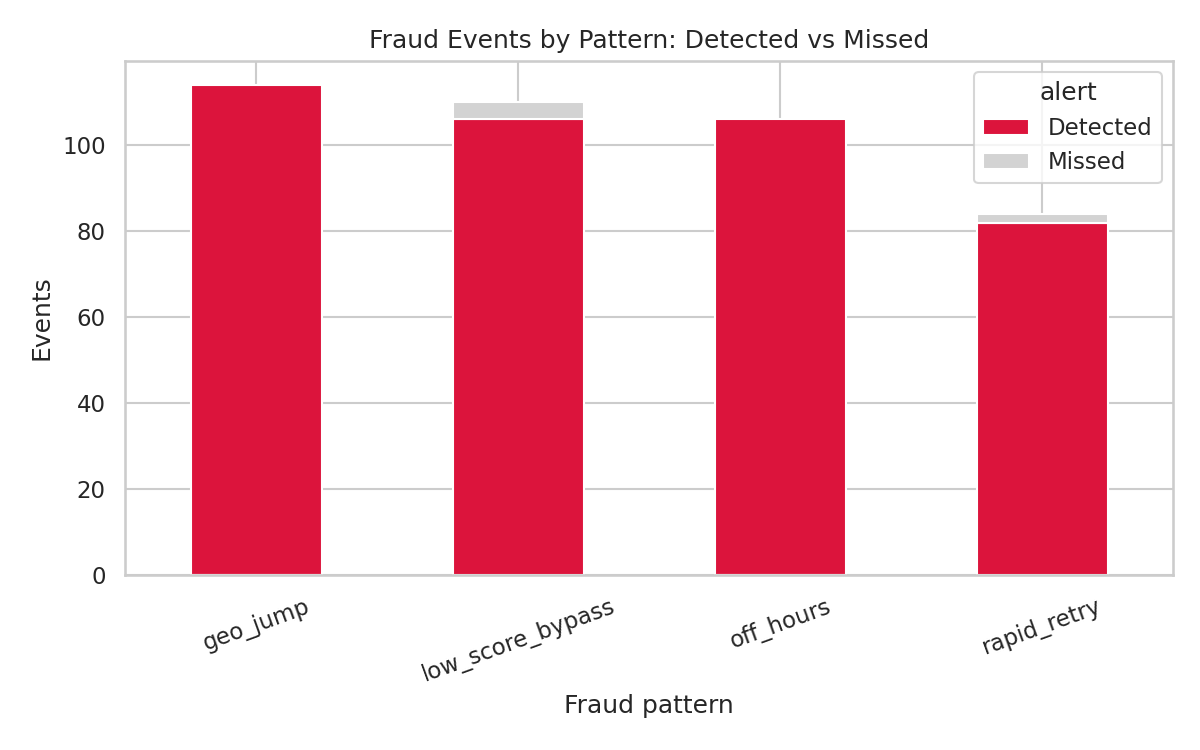

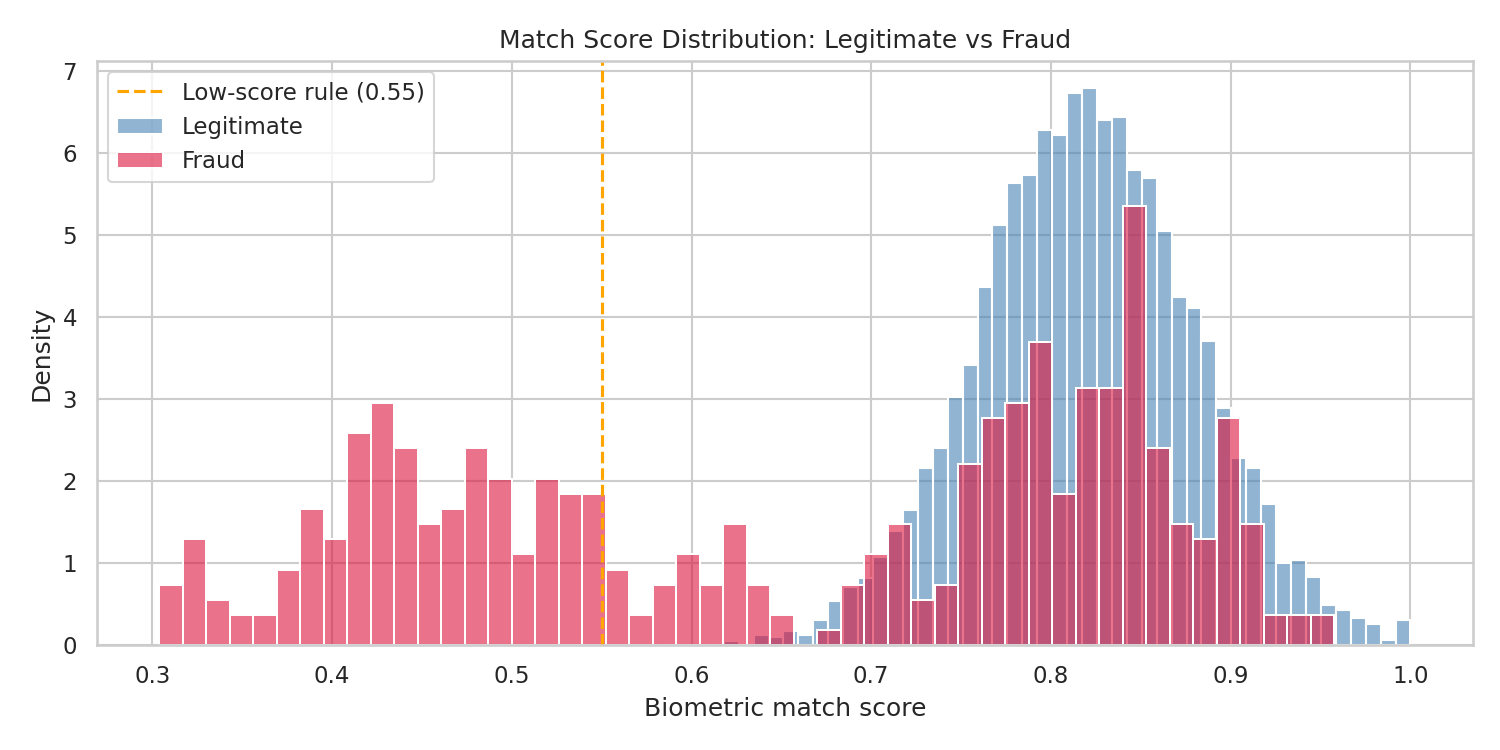

In [8]:
display(Image('reports/fraud_by_pattern.png', width=600))
display(Image('reports/match_score_dist.png', width=700))

## 5. Investigation queue
Accounts ranked by alert count, using only fields an analyst would see (no fraud labels).

In [9]:
(df[df['alert'] == 1].groupby('user_id')
   .agg(alerts=('alert', 'sum'), mean_score=('match_score', 'mean'),
        locations=('location', lambda s: ', '.join(sorted(s.unique()))))
   .sort_values('alerts', ascending=False).head(10))

,alerts,mean_score,locations
user_id,,,
USR-0085,8,0.703612,"Lagos, London, Singapore"
USR-0171,7,0.657843,"New York, Singapore"
USR-0021,6,0.542483,"Lagos, Manchester"
USR-0077,6,0.689167,"Berlin, Manchester, Singapore"
USR-0106,6,0.614017,"Lagos, Manchester"
USR-0097,6,0.718400,"Lagos, New York, Singapore"
USR-0092,5,0.527680,"London, New York, Singapore"
USR-0122,5,0.701900,"Berlin, Manchester, New York"
USR-0066,5,0.589400,"Lagos, London"


## 6. Limitations
- The data is synthetic, so detection is easier than on real traffic (e.g. no legitimate user ever logs in off-hours).
- Isolation Forest sensitivity (6%) sits close to the true fraud rate, which production would not know; in practice it would be tuned on analyst feedback.
- Hours 02-04 and 22 contain only fraud, so time-of-day findings reflect the generator.

The full PDF report is in `reports/biometric_fraud_report.pdf`.